#Spam Email Detection System


---
## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Step 2: Data Collection


In [2]:
# Load the CSV dataset
data = pd.read_csv('spam.csv')
print(f"Dataset loaded: {data.shape[0]} rows, {data.shape[1]} columns")
data.head()

Dataset loaded: 5572 rows, 2 columns


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Check column names
print("Columns:", data.columns.tolist())

Columns: ['Category', 'Message']


In [4]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Label distribution:
Category
ham     4825
spam     747
Name: count, dtype: int64


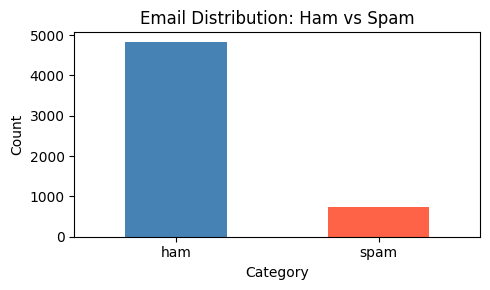

In [5]:
# Check class distribution
print("Label distribution:")
print(data['Category'].value_counts())

# Visualize distribution
plt.figure(figsize=(5, 3))
data['Category'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Email Distribution: Ham vs Spam')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Step 3: Preprocessing


In [6]:
# Check for missing values
print("Missing values:")
print(data.isna().sum())

Missing values:
Category    0
Message     0
dtype: int64


In [7]:
# Drop any missing rows if present
data = data.dropna(subset=['Message', 'Category'])

# Encode labels: spam=1, ham=0
data['Spam'] = data['Category'].apply(lambda x: 1 if x == 'spam' else 0)

print("Label encoding done:")
print(data[['Category', 'Spam']].head(5))

Label encoding done:
  Category  Spam
0      ham     0
1      ham     0
2     spam     1
3      ham     0
4      ham     0


---
## Step 4: Feature Extraction using CountVectorizer


In [8]:
# Split into features and labels
X = data['Message']
y = data['Spam']

# Train/Test split — 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 4179
Testing samples  : 1393


---
## Step 5: Model Training — Multinomial Naive Bayes


In [9]:
# Build the ML Pipeline
# Pipeline Flow: Raw Text → CountVectorizer → MultinomialNB → Prediction
clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

# Train the model
clf.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


---
## Step 6: Prediction & Evaluation

In [10]:
# Predict on test set
y_pred = clf.predict(X_test)

# Evaluation Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 40)
print("     MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print("=" * 40)

     MODEL EVALUATION RESULTS
  Accuracy  : 98.85%
  Precision : 97.75%
  Recall    : 93.55%
  F1 Score  : 95.60%


In [11]:
# Full classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham (Not Spam)', 'Spam']))

Classification Report:
                precision    recall  f1-score   support

Ham (Not Spam)       0.99      1.00      0.99      1207
          Spam       0.98      0.94      0.96       186

      accuracy                           0.99      1393
     macro avg       0.98      0.97      0.97      1393
  weighted avg       0.99      0.99      0.99      1393



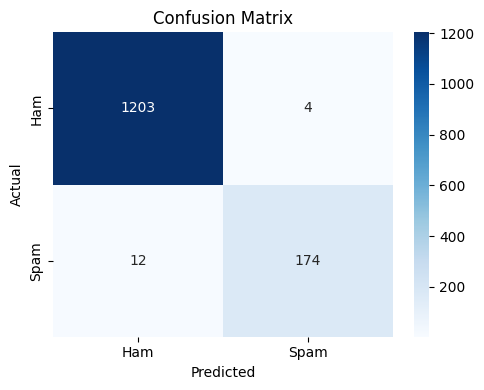

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

---
## Step 7: Test With Custom Emails


In [13]:
# Test with sample emails (from proposal Section 7)
test_emails = [
    'Sounds great! Are you home now?',
    'Congratulations! You have WON $1,000,000. Call now to claim your prize!',
    'Please review the attached project report before the deadline tomorrow.',
    'FREE OFFER! Buy cheap meds online. No prescription needed. Act NOW!!!'
]

predictions = clf.predict(test_emails)
labels = ['SPAM' if p == 1 else 'HAM (Not Spam)' for p in predictions]

print("Email Classification Results:")
print("-" * 60)
for email, label in zip(test_emails, labels):
    print(f"Email  : {email[:55]}..." if len(email) > 55 else f"Email  : {email}")
    print(f"Result : {label}")
    print("-" * 60)

Email Classification Results:
------------------------------------------------------------
Email  : Sounds great! Are you home now?
Result : HAM (Not Spam)
------------------------------------------------------------
Email  : Congratulations! You have WON $1,000,000. Call now to c...
Result : SPAM
------------------------------------------------------------
Email  : Please review the attached project report before the de...
Result : HAM (Not Spam)
------------------------------------------------------------
Email  : FREE OFFER! Buy cheap meds online. No prescription need...
Result : HAM (Not Spam)
------------------------------------------------------------


In [14]:
# Interactive: classify your own email
user_email = input("Enter an email to classify: ")
result = clf.predict([user_email])[0]
print(f"\nResult: {'SPAM 🚨' if result == 1 else 'HAM ✅ (Not Spam)'}")

Enter an email to classify: Dear User,  We noticed unusual activity connected with your recent account access attempt from multiple regions. To avoid suspension, please confirm your identity within the next 12 hours or your access may be temporarily limited.  Your invoice reference: #A91X-443-PENDING Security verification token: 77XZ-991-ALERT  Failure to respond could result in:  * Delayed processing * Restricted services * Possible permanent review status  Click the secure verification portal below immediately:  http://secure-confirm-access-check.net/login/verify-user  If you already verified your information, please ignore this message and do not reply.  Best Regards, Customer Protection Team Global Secure Processing Unit

Result: SPAM 🚨


---
## Step 8: Interactive GUI — Email Spam Detector


In [15]:
# ─── INTERFACE CELL (no changes to model or data above) ───
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ── Styling ──────────────────────────────────────────────
display(HTML("""
<style>
  .spam-card {
    background: #1e1e2e;
    border-radius: 14px;
    padding: 28px 32px;
    max-width: 680px;
    margin: 12px auto;
    box-shadow: 0 4px 24px rgba(0,0,0,0.35);
    font-family: 'Segoe UI', sans-serif;
  }
  .spam-title {
    color: #cdd6f4;
    font-size: 20px;
    font-weight: 600;
    margin-bottom: 4px;
  }
  .spam-sub {
    color: #6c7086;
    font-size: 13px;
    margin-bottom: 20px;
  }
  .result-spam {
    background: #2d1b1b;
    border: 1.5px solid #f38ba8;
    border-radius: 10px;
    padding: 16px 20px;
    color: #f38ba8;
    font-size: 18px;
    font-weight: 700;
    text-align: center;
    margin-top: 16px;
  }
  .result-ham {
    background: #1b2d1b;
    border: 1.5px solid #a6e3a1;
    border-radius: 10px;
    padding: 16px 20px;
    color: #a6e3a1;
    font-size: 18px;
    font-weight: 700;
    text-align: center;
    margin-top: 16px;
  }
  .result-empty {
    background: #2a2a3e;
    border: 1.5px solid #45475a;
    border-radius: 10px;
    padding: 16px 20px;
    color: #6c7086;
    font-size: 14px;
    text-align: center;
    margin-top: 16px;
  }
  .history-row-spam { color: #f38ba8; font-size: 13px; padding: 4px 0; border-bottom: 1px solid #313244; }
  .history-row-ham  { color: #a6e3a1; font-size: 13px; padding: 4px 0; border-bottom: 1px solid #313244; }
  .history-label { font-weight: 600; min-width: 120px; display: inline-block; }
  .history-email { color: #bac2de; }
</style>
"""))

# ── Widgets ───────────────────────────────────────────────
title_html = widgets.HTML(
    '<div class="spam-title">📧 Email Spam Detector</div>'
    '<div class="spam-sub">Powered by Multinomial Naive Bayes · CountVectorizer</div>'
)

email_input = widgets.Textarea(
    placeholder='Paste or type an email message here...',
    layout=widgets.Layout(width='100%', height='110px')
)

classify_btn = widgets.Button(
    description='  Classify Email',
    button_style='',
    icon='search',
    layout=widgets.Layout(width='180px', height='38px')
)
classify_btn.style.button_color = '#89b4fa'
classify_btn.style.text_color   = '#1e1e2e'
classify_btn.style.font_weight  = 'bold'

clear_btn = widgets.Button(
    description='Clear',
    button_style='',
    icon='times',
    layout=widgets.Layout(width='90px', height='38px')
)
clear_btn.style.button_color = '#45475a'
clear_btn.style.text_color   = '#cdd6f4'

result_out  = widgets.Output()
history_out = widgets.Output()
history     = []

# ── Callbacks ─────────────────────────────────────────────
def on_classify(b):
    text = email_input.value.strip()
    with result_out:
        clear_output(wait=True)
        if not text:
            display(HTML('<div class="result-empty">⚠️ Please enter an email message first.</div>'))
            return
        pred = clf.predict([text])[0]
        if pred == 1:
            display(HTML('<div class="result-spam">🚨 SPAM — This email looks suspicious!</div>'))
            history.append(('SPAM', text))
        else:
            display(HTML('<div class="result-ham">✅ HAM — This email looks safe.</div>'))
            history.append(('HAM', text))
    _refresh_history()

def on_clear(b):
    email_input.value = ''
    with result_out:
        clear_output()
        display(HTML('<div class="result-empty">Result will appear here after classification.</div>'))

def _refresh_history():
    with history_out:
        clear_output(wait=True)
        if not history:
            return
        rows = ''.join(
            f'<div class="history-row-{label.lower()}">' +
            f'<span class="history-label">{label}</span>' +
            f'<span class="history-email">{email[:80]}...</span></div>'
            if len(email) > 80 else
            f'<div class="history-row-{label.lower()}">' +
            f'<span class="history-label">{label}</span>' +
            f'<span class="history-email">{email}</span></div>'
            for label, email in reversed(history[-8:])
        )
        display(HTML(
            '<div style="margin-top:20px;">'
            '<div style="color:#6c7086;font-size:12px;margin-bottom:6px;text-transform:uppercase;letter-spacing:1px;">Recent Classifications</div>'
            + rows + '</div>'
        ))

classify_btn.on_click(on_classify)
clear_btn.on_click(on_clear)

# ── Initial placeholder result ────────────────────────────
with result_out:
    display(HTML('<div class="result-empty">Result will appear here after classification.</div>'))

# ── Layout & Display ──────────────────────────────────────
btn_row = widgets.HBox(
    [classify_btn, clear_btn],
    layout=widgets.Layout(gap='10px', margin='10px 0 0 0')
)

ui = widgets.VBox(
    [title_html, email_input, btn_row, result_out, history_out],
    layout=widgets.Layout(padding='28px 32px', max_width='680px')
)

display(ui)